### Univariate Analysis kyun important hai?

####  Model ya multivariate analysis se pehle hume yeh pata hona chahiye:               
 - Data skewed hai ya normal?
 - Outliers hain ya nahi?
 - Categories balanced hain ya nahi?

Agar yeh miss ho gaya →
❌ wrong assumptions
❌ poor model performance

In [11]:
import pandas as pd 

df = pd.DataFrame({
    'salary': [45000.5, 52000.0, 61000.75 ],
    'City': ['Mumbai', 'Delhi', 'Mumbai'],
    'is_active': [False, True,False]
})

In [3]:
## 1.Univariate Analysis for Numerical Data 
# step 1: Descriptive statistics 

df['salary'].describe()

# Isse milta Hai:
#   - mean
#   - median(50%)
#   - min/max
#   - quartiles

# TIP:
#  - Mean != Median -> skewed data 
#  - Max bahut high -> passible outlier

count        3.000000
mean     52667.083333
std       8020.956935
min      45000.500000
25%      48500.250000
50%      52000.000000
75%      56500.375000
max      61000.750000
Name: salary, dtype: float64

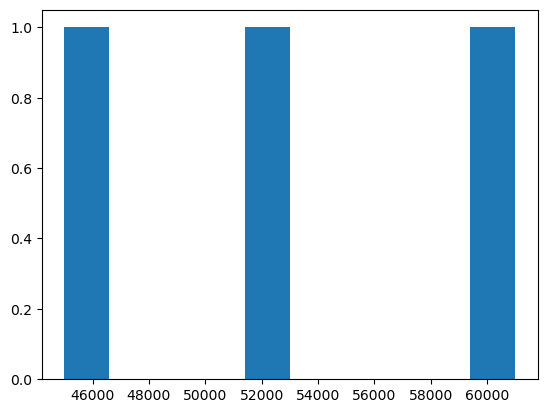

In [ ]:
# Step 2: Distribution (histogram)

import matplotlib.pyplot as plt

plt.hist(df['salary'], bins=10)
plt.show()

# Important 
#   - Right skewed -> income, sales
#   - Left skewed  -> scores, marks
#   - bell shape   -> normal distribution 

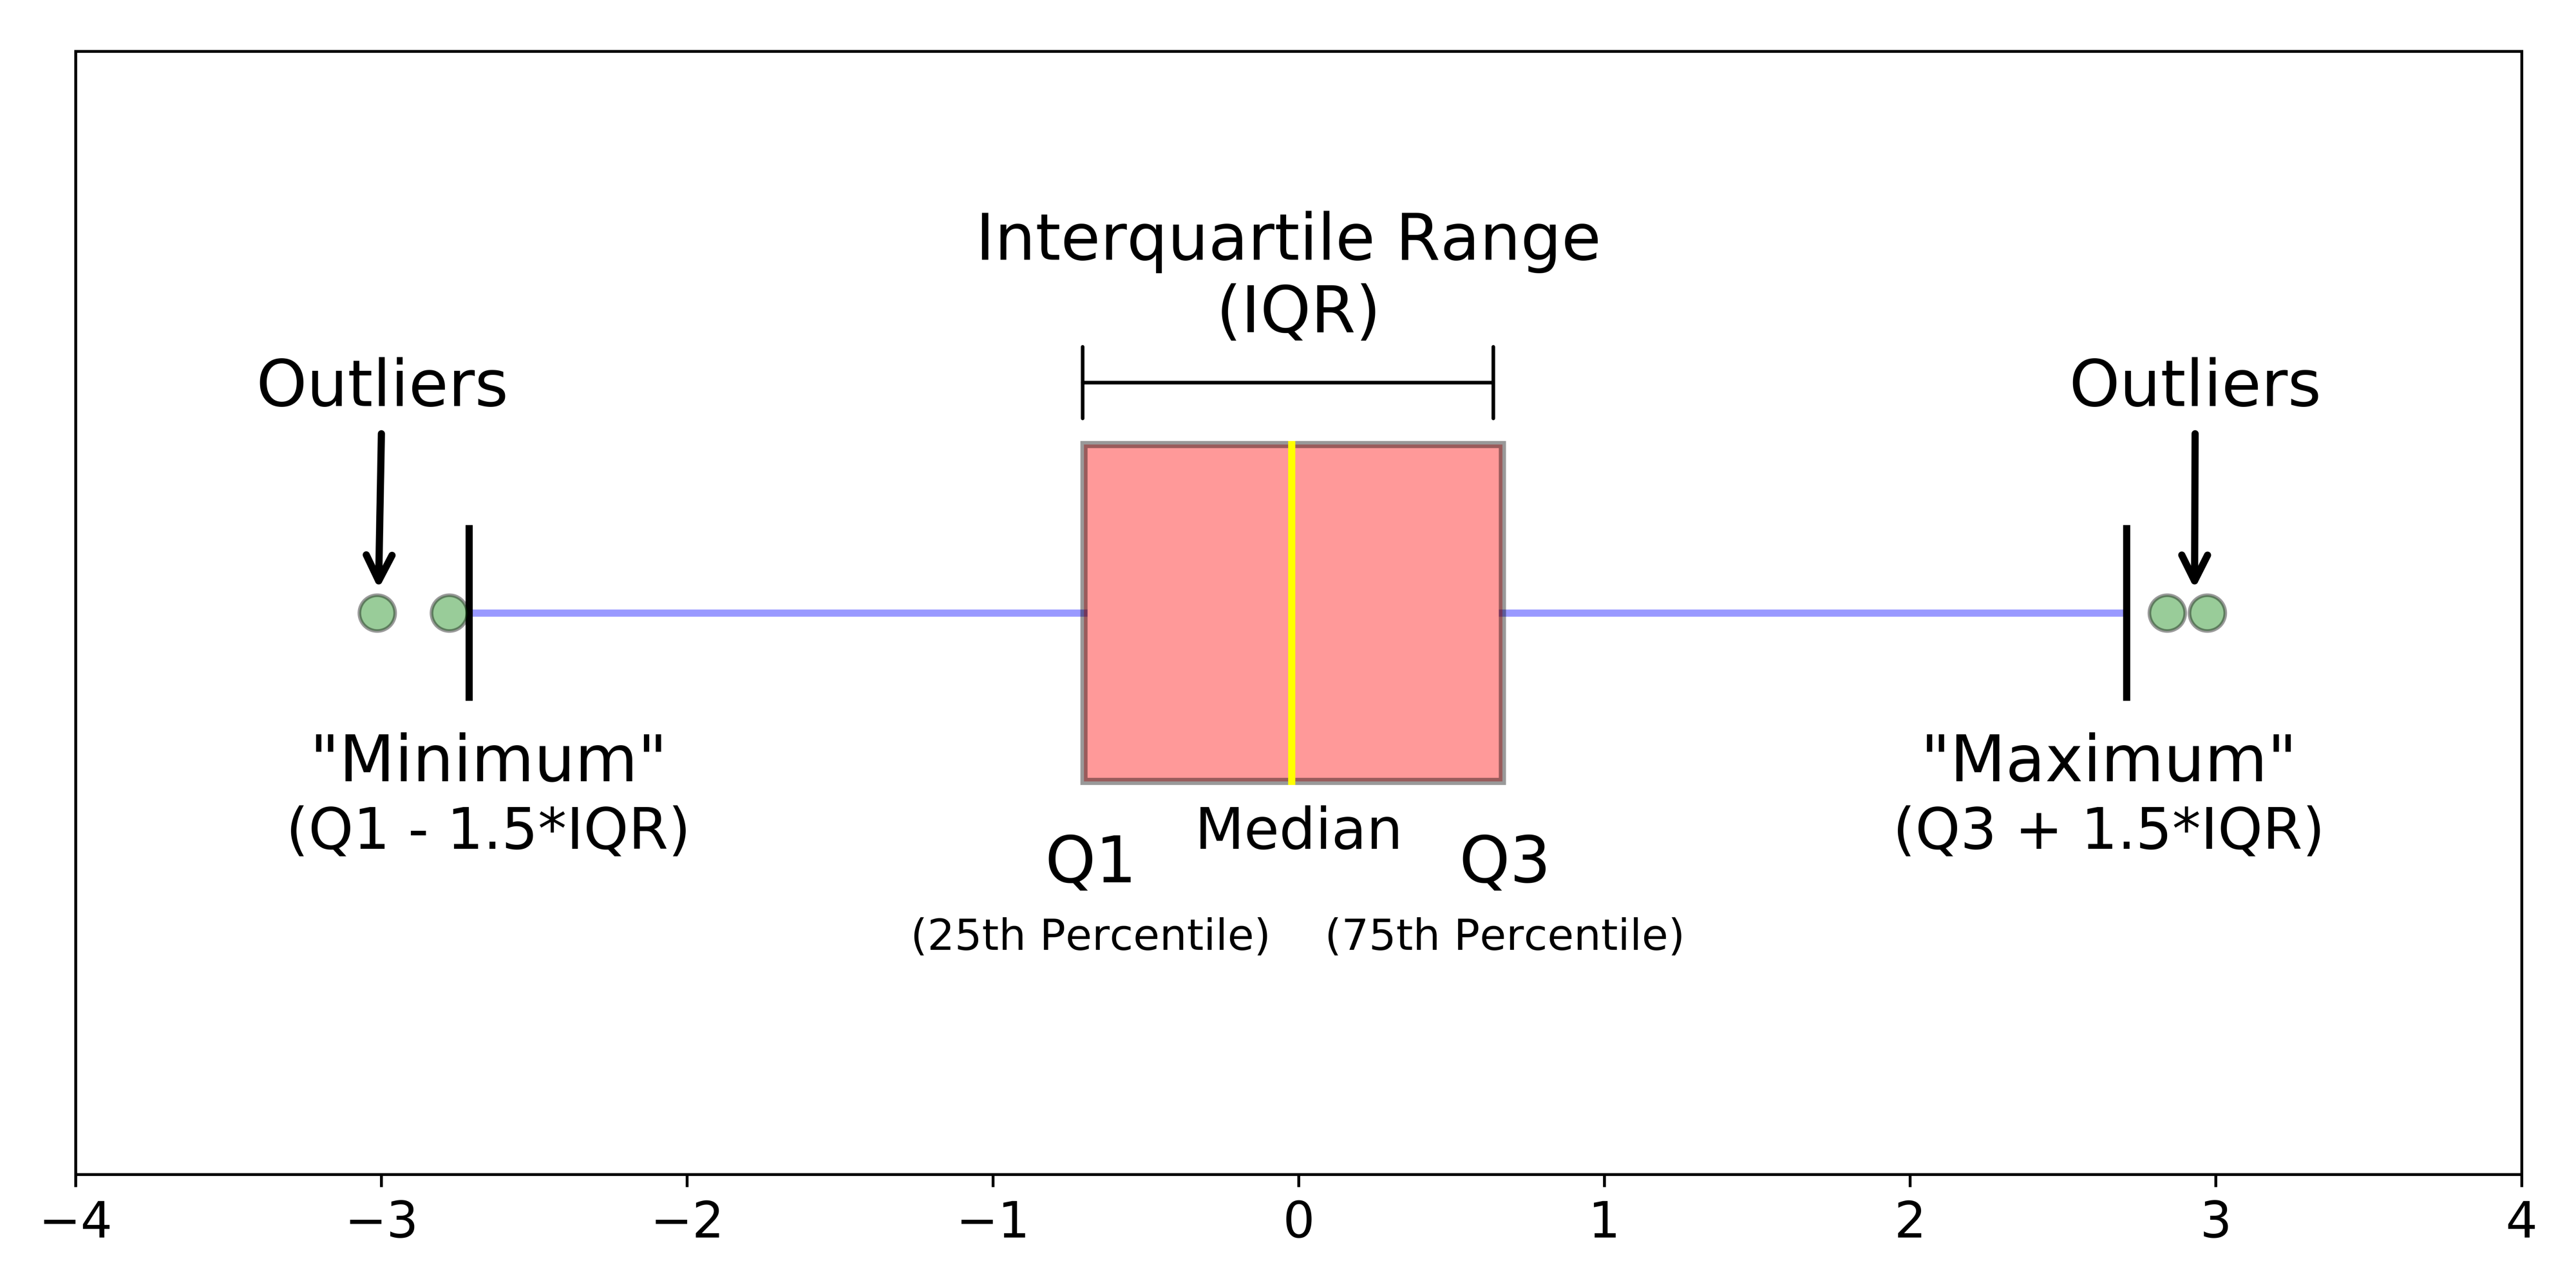

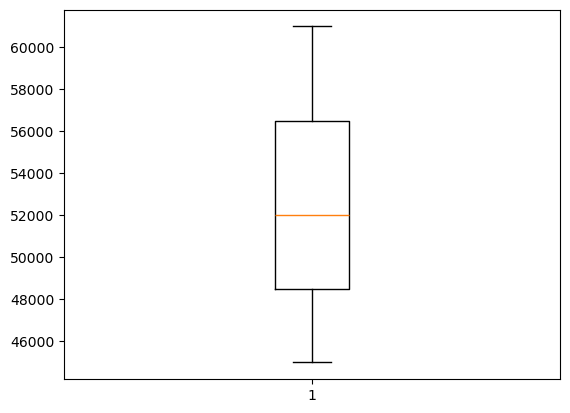

In [ ]:
# Step 3: Boxplot(outliers check)

plt.boxplot(df['salary'])
plt.show()

# Rule:
# - Dots outside whiskers = potential outliers
#       - Delete tabhi karo jab business logic allow kare.

In [8]:
# 2.Univeriate Analysis for categorical data 
# Step 1: Frequency Counts 

df['City'].value_counts()

# Question to ask:
#   - kaunse category dominant hai?
#   - kya imbalance hai?

City
Mumbai    2
Delhi     1
Name: count, dtype: int64

In [9]:
# Step 2: Percentage Distribution 

df['City'].value_counts(normalize=True) * 100

# Use case:
#   - Classifications Problems me clss imbalance dtect hota hai. 

City
Mumbai    66.666667
Delhi     33.333333
Name: proportion, dtype: float64

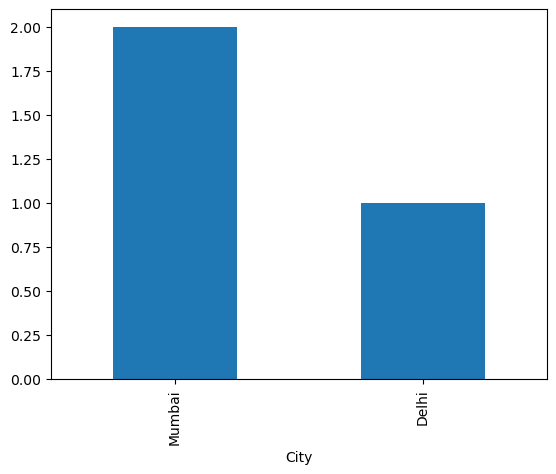

In [10]:
# Step 3: Bar Chart 

df['City'].value_counts().plot(kind='bar')
plt.show()

In [13]:
# 3 Univeriate Analysis for Boolean data 

df['is_active'].value_counts()

# Mostly binary decision:
#   - Highly imbalanced -> resampling needed 
#   - balance -> good for modeling 

is_active
False    2
True     1
Name: count, dtype: int64

In [ ]:
# 4. Univeriate Analysis for Date/Time

df['date'].min(), df['date'].max()

df['date'].dt.year.value_count()

# Check:
#   - Time range
#   - Missing periods 
#   - Data freshness

### Bivariate analysis

In [15]:
# Bivariate Analysis = do variables ka relationship samajhna
#       - 'Ek variable doosre ko kaise affect karta hai?

# Bivariate Analysis kyun important hai?
#   - Features ka target se relation samajhne ke liya 
#   - Correlation & patterns detect karne ke liya 
#   - Useless columns drop karne ke liya 

# Rule:
# Univariate = column ko samajho 
# bivariate = relationship samajho

In [ ]:
# Types of Bivariate Analysis 

#| Variable 1  | Variable 2  | Technique            |
#| ----------- | ----------- | -------------------- |
#| Numerical   | Numerical   | Scatter, Correlation |
#| Numerical   | Categorical | Boxplot              |
#| Categorical | Categorical | Crosstab, Bar chart  |
#| Feature     | Target      | MUST analyze         |


In [ ]:
# 1. Numerical vs Numerical 
# Scatter Plot(most important)

import matplotlib.pyplot as plt 

plt.scatter(df['experience'], df['salary'])
plt.xlabel('Experience')
plt.ylabel()
plt.show()

# How to interpretation:
#   - Upward trend -> positive relation
#   - Downward -> negative
#   - No patten -> weak/no relation

In [ ]:
# Correlation (Quick check)

df[['experience', 'salary']].corr()

# Correlation range:
# - +1 -> strong positive
# - 0  -> no relation
# - -1 -> strong negative 

#### Correlation != causation 

In [ ]:
# 2. Numerical vs Categorical 
# Boxplot(Best choice)

df.boxplot(column='salary', by='city')
plt.show()

# How to Interpretation:
#   - Mediam comparison 
#   - Spread(IQR)
#   - City-wise salary difference 

# Interview Tip:
# 'Boxplot shows distribution, not jest average.'

In [ ]:
# 3. Categorical vs Categorical 
# Crosstab(Frequency relationship)

pd.crosstab(df['gender'], df['purchased'])

pd.crosstab(df['gender'], df['purchased'], normalize='index') * 100

# Use case:
#   - Conversion rate
#   - Churn analysis
#   - Survey analysis

In [ ]:
# Feature vs Target (Most Important)
# Target ke saath har feature ka relation check karo.

# Numerical Feature vs Target

df.groupby('purchased')['Salary'].mean()

# Question:
# Buyers vs non-buyers salary me farak?

In [ ]:
# Categorical Feature vs Target 

pd.crosstab(df['city'], df['purchased'], normalize='index') * 100

# Question:
#   - Kaunse city me conversion zyada?

In [16]:
# Multivariate Analysis 
# Multivariate -> 3 ya usse zyada variables ek saath analysis 

# Multivariate Analysis kyun important hai?
# Example:
#   - Salary sirf experience pe depend nahi karti
#   - Customer srif age se purchase nahi karta.
# Multiple factors together impact karte hain.


In [17]:
# Core Multivariate Techiniques 
# | Technique                  | Kab use kare             |
# | -------------------------- | ------------------------ |
# | Pairplot                   | Quick relationship scan  |
# | Correlation matrix         | Linear relationships     |
# | Groupby (multiple columns) | Business insights        |
# | Pivot tables               | Aggregated patterns      |
# | Multivariate plots         | Contextual understanding |


In [ ]:
# 1. Pairwise Relationship (sub variable ka quick scan)

import seaborn as sns

sns.pairplot(df[['age', 'experience', 'salary']])

# How to interpretation:
#   - Linear trend?
#   - Clusters?
#   - Outliers?
# -> Large Dataset -> avoid pairplot(slow + messy)

In [ ]:
# 2. Correlation Matris (Numerical only)

df[['age', 'experience', 'salary']].corr()

# Heatmap for visualization:

sns.heatmap(df.corr(), annot=True)

# Use case:
#   - Multicollinearitly detect karna 
#   - Redundant features identify karna 

In [ ]:
# 3. Groupby with Multiple Columns 
# Business-style multivariate analysis.

df.groupby(['City', 'Gender'])['salary'].mean()

# Question 
# City + gender ka combined impact salary pe? 

In [ ]:
# 4. Pivit Table(Very Powerfull)
pd.pivot_table(
    df,
    values='salary',
    index='city',
    columns='gender',
    aggfunc='mean'
)

In [ ]:
# 5. Hue-based Multivariate plot
# Ek plot me multiple dimensions.

sns.scatterplot(
    data=df,
    x='experience',
    y='salary',
    hue='city'
)

# how to interpretation:
#       - City-wise clusters
#       - Different trends per category 

In [ ]:
# Target-oriented Multivariabte Analysis

sns.boxplot(
    data=df,
    x='purchased',
    y='salary',
    hue='gender'
)

# Purpose:
#   - Feature interaction with rarget 

#### data profiling

In [ ]:
# Data Profilling 
# data profiling is done during data understanding
# Dataset-level Summary

# Summary Statistics kyun important hai?
#   - Data ka range
#   - Central tendency
#   - Spread
#   - Outliers ka hint


df.shape
df.info()
df.describe(include="all")

# describe(include="all") gives:
#   - Numeric stats
#   - Categorical counts
#   - Unique values
#   - Most frequent value


In [19]:
# Distribution Analysis
# Distribution Analysis kyun important hai?
#   - Mean misleading ho sakta hai
#   - Model assumptions toot sakti hain
#   - Outliers galat handle ho jaate hain

# Numerical Data Distribution
#   - Normal Distribution (Ideal but Rare)
#   - Right-Skewed Distribution (MOST COMMON)
#   - Left-Skewed Distribution
#   - Boxplot – Distribution + Outliers
#   - Density Plot (Smooth Distribution)
#   - Categorical Distribution

In [20]:
# Outlier detection
# Outlier Detection kyun important hai?
#   - Mean / std ko distort karta hai
#   - Model performance bigaad sakta hai
#   - Kabhi-kabhi high-value insight hota hai (VIP customers, fraud)

# Visual Detection (Always start here)
#   - Boxplot (Fastest way)
#   - Scatter Plot (Bivariate context)



In [ ]:
# Outlier detection

# Statistical Methods (Core Techniques)
# 1. IQR Method (MOST USED)

Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["salary"] < lower) | (df["salary"] > upper)]

# Why IQR is preferred:
#   - Skewed data me bhi kaam karta
#   - Mean pe depend nahi



In [ ]:
# 2. Z-Score Method
# Normal distribution ke liye better.

from scipy import stats

z_scores = stats.zscore(df["salary"])
df[abs(z_scores) > 3]

#Rule:
#   - |Z| > 3 → outlier

#Limitation:
#   - Highly skewed data me misleading

In [ ]:
# 3. Percentile / Quantile Capping
# Detection + treatment ek saath.

lower = df["salary"].quantile(0.01)
upper = df["salary"].quantile(0.99)

df[(df["salary"] < lower) | (df["salary"] > upper)]

# Use case:
# Business data (revenue, transactions)

In [21]:
## Correlation Analysis
# Correlation Analysis kyun important hai?
#   - Strong relationship wale features identify karna
#   - Redundant features (multicollinearity) detect karna
#   - Feature vs Target strength samajhna

# Rule:
#   - Correlation = direction + strength (not causation)

# Correlation ka Meaning 
#| Value | Meaning            |
#| ----- | ------------------ |
#| +1    | Perfect positive   |
#| 0     | No linear relation |
#| -1    | Perfect negative   |


In [ ]:
# Pearson Correlation (MOST USED)
# Linear relationship measure karta hai

df[["experience", "salary"]].corr()

# Interpretation guideline (practical):
#       - 0.7 – 1.0 → strong
#       - 0.3 – 0.7 → moderate
#       - < 0.3 → weak

# Weak ≠ useless (non-linear ho sakta hai)

In [ ]:
# Correlation Matrix (Multiple variables)

corr_matrix = df.corr()
corr_matrix

# Ek saath saare numeric features ka overview

In [ ]:
# Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Heatmap se kya pata chalta hai?
#   - Strong relations quickly
#   - Multicollinearity
#   - Feature clusters

In [ ]:
# Feature vs Target Correlation (MOST IMPORTANT)
df.corr()["target"].sort_values(ascending=False)

#Use case:
#   - High correlation → strong feature candidate
#   - Near zero → weak linear relation

# Linear model ke liye bahut important